### Практическая работа №3: Байесовская классификация

Выполнил: Чашин Денис, ЕТ-128

In [7]:
# Библиотеки
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import warnings
warnings.filterwarnings("ignore")

## Описание датасета Iris

**Iris** - датасет для задач классификации: 150 объектов, 3 класса (виды ириса), 4 числовых признака.
Признаки - длина, ширина чашелистика и длина, ширина лепестка.


In [8]:
# Загрузка датасета Iris
iris = datasets.load_iris()
X = iris.data
y = iris.target

# Краткая сводка по данным
df_iris = pd.DataFrame(X, columns=iris.feature_names)
df_iris["target"] = y
df_iris["species"] = df_iris["target"].map({i: name for i, name in enumerate(iris.target_names)})

print("Размерность X:", X.shape)
print("Классы:", list(iris.target_names))
print("\nПервые 5 строк:")
df_iris.head()


Размерность X: (150, 4)
Классы: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

Первые 5 строк:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [9]:
# Варьируем соотношения мощностей обчающей (от 60 до 90 % с шагом 5) и тестовой выборок
train_ratios = list(range(60, 95, 5))
acc_list = []
prec_list = []
rec_list = []
f1_list = []

In [10]:
# Эксперимент: обучение/оценка Gaussian Naive Bayes для разных долей train
for tr in train_ratios:
    ratio = tr / 100
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, train_size=ratio, random_state=42, stratify=y
    )

    model = GaussianNB()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc_list.append(accuracy_score(y_test, y_pred))
    prec_list.append(precision_score(y_test, y_pred, average='macro'))
    rec_list.append(recall_score(y_test, y_pred, average='macro'))
    f1_list.append(f1_score(y_test, y_pred, average='macro'))

# Таблица результатов
results = pd.DataFrame({
    "train size %": train_ratios,
    "test size %": [100 - x for x in train_ratios],
    "accuracy": acc_list,
    "precision": prec_list,
    "recall": rec_list,
    "f1": f1_list
})

results


,train size %,test size %,accuracy,precision,recall,f1
0,60,40,0.933333,0.936027,0.933333,0.933166
1,65,35,0.924528,0.929167,0.925926,0.925697
2,70,30,0.911111,0.915535,0.911111,0.910714
3,75,25,0.921053,0.924603,0.923077,0.922963
4,80,20,0.966667,0.969697,0.966667,0.966583
5,85,15,0.913043,0.916667,0.916667,0.916667
6,90,10,0.866667,0.866667,0.866667,0.866667


In [14]:
# Визуализация: отдельные графики по метрикам + общий график
import os

FIG_DIR = "figs"
os.makedirs(FIG_DIR, exist_ok=True)

def plot_one_metric(x, y, title, ylabel, filename):
    plt.figure(figsize=(8, 5))
    plt.plot(x, y, marker="o")
    plt.title(title)
    plt.xlabel("Процент обучающей выборки (%)")
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.tight_layout()
    out_path = os.path.join(FIG_DIR, filename)
    plt.savefig(out_path, dpi=200)
    plt.show()
    return out_path

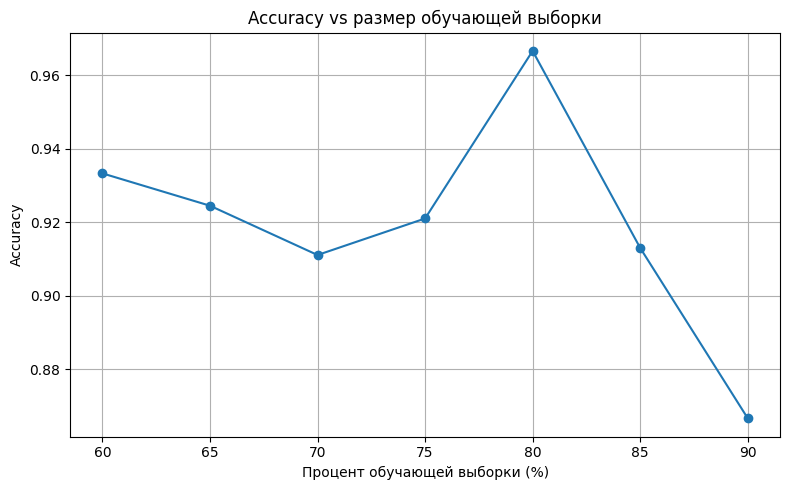

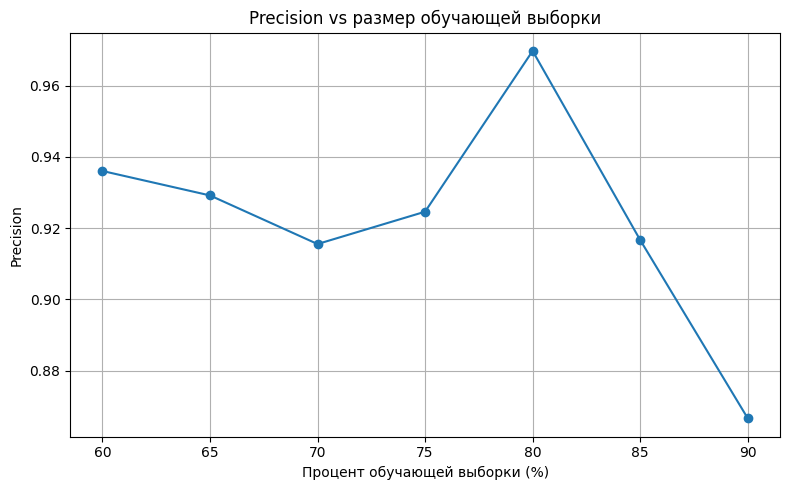

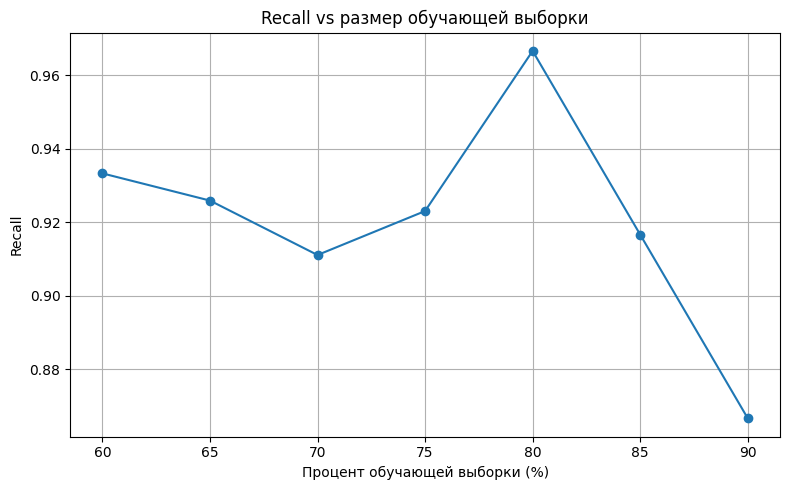

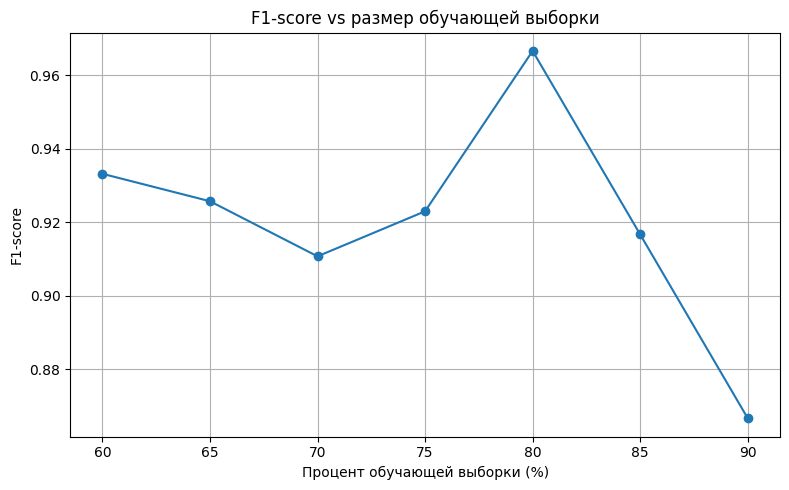

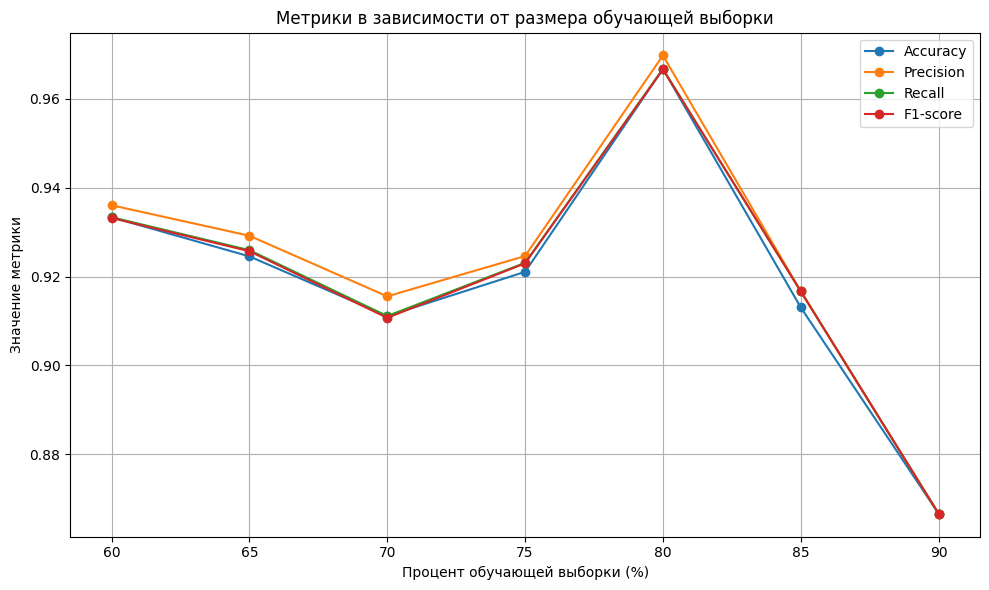

In [16]:
acc_path = plot_one_metric(train_ratios, acc_list,
                           "Accuracy vs размер обучающей выборки",
                           "Accuracy", "accuracy.png")

prec_path = plot_one_metric(train_ratios, prec_list,
                            "Precision vs размер обучающей выборки",
                            "Precision", "precision.png")

rec_path = plot_one_metric(train_ratios, rec_list,
                           "Recall vs размер обучающей выборки",
                           "Recall", "recall.png")

f1_path = plot_one_metric(train_ratios, f1_list,
                          "F1-score vs размер обучающей выборки",
                          "F1-score", "f1.png")

# Общий график всех метрик
plt.figure(figsize=(10, 6))
plt.plot(train_ratios, acc_list, label="Accuracy", marker="o")
plt.plot(train_ratios, prec_list, label="Precision", marker="o")
plt.plot(train_ratios, rec_list, label="Recall", marker="o")
plt.plot(train_ratios, f1_list, label="F1-score", marker="o")

plt.title("Метрики в зависимости от размера обучающей выборки")
plt.xlabel("Процент обучающей выборки (%)")
plt.ylabel("Значение метрики")
plt.grid(True)
plt.legend()
plt.tight_layout()

all_path = os.path.join(FIG_DIR, "all_metrics.png")
plt.savefig(all_path, dpi=200)
plt.show()